In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib
import matplotlib.pyplot as plt
import scipy.stats
import torch

import block_formats.quantisation
import plot_utils

matplotlib.rcParams.update(
    {
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.edgecolor": "none",
        "legend.fontsize": "11",
        "lines.markersize": 3,
    }
)

On branch master
Your branch is up to date with 'origin/master'.

nothing to commit, working tree clean
Error running "git -C overleaf commit -m 'Update figures' --quiet" -- aborting


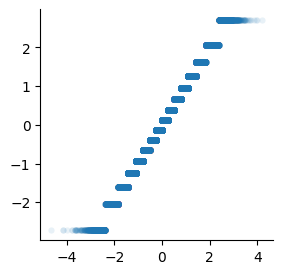

In [ ]:
def example_crd():
    b = 4
    p = torch.linspace(0, 1, 2**b + 2)
    Q = torch.tensor(scipy.stats.norm.ppf(p[1:-1], scale=3**0.5))

    def quantise(x): return torch.bucketize(x, (Q[1:] + Q[:-1]) / 2)
    def dequantise(i): return Q[i]
    # IGNORE
    return Q, quantise, dequantise  # IGNORE

# Checks
Q, quantise, dequantise = example_crd()
X = torch.randn(2**16, generator=torch.Generator().manual_seed(100))
fmt = block_formats.quantisation.crd_gauss(4)
torch.testing.assert_close(torch.tensor(fmt.values), Q.float())
torch.testing.assert_close(fmt.quantise(X), dequantise(quantise(X)).float())
_, ax = plt.subplots(figsize=(3, 3))
ax.scatter(X, dequantise(quantise(X)), s=20, alpha=0.1, linewidths=0)

plot_utils.save_code(example_crd)